In [1]:
import time
import copy
import itertools
import numpy as np
import scipy as sp
import scipy.special as ssp
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as pat
sns.set_style('ticks')
rgblist = sns.color_palette('tab10' )
from matplotlib.font_manager import FontProperties

In [2]:
class remote_estm():
    def __init__(self):
        self.d_A = 0
        self.d_S = 2
        self.a = 0.9
        self.sigma = 0.5
        self.p = np.array([[0.6, 0.4],[0.5, 0.5]])
        self.lmbda = 1.0
        
        self.state_space = ([-np.inf, 0], [np.inf, 1])
        self.action_space = (0,1)
        
        self.state = None
        self.reward = None
        
    def reset(self):
        self.state = None
        self.ar_state = None
        self.ch_state = None
        self.noise = None
        self.reward = None
    
    def init(self):
        self.state = np.zeros((self.d_S))
        self.ar_state = 0
        self.ch_state = 0
        return self.state
    
    def step(self, action):
        self.ch_state = np.random.choice([0,1],p=self.p[self.ch_state])
        self.noise = self.sigma*np.random.normal()
        self.ar_state = self.a*self.ar_state + self.noise
        if self.ch_state*action == 1:
            self.state[0] = self.p[1,1]
            self.state[1] = self.noise
        else:
            self.state[1] = self.a*self.state[1] + self.noise
            if action*(1 - self.ch_state) == 1:
                self.state[0] = self.p[0,1]
            else:
                self.state[0] = self.state[0]*self.p[1,1] + (1 - self.state[0])*self.p[0,1]
        self.reward = self.get_reward(action)
        return self.state, self.reward
    
    def get_reward(self, action):
        return - self.state[1]**2 - self.lmbda*action

In [3]:
class Cell:
    def __init__(self, start, end, d_S=2, parent=None):
        self.d_S = d_S
        self.start = start
        self.end = end
        self.center = [0.5*(start[i]+end[i]) for i in range(self.d_S)]
        self.diam = end[0] - start[0]
        self.parent = parent
        self.children = None
        
        self.active = True
        if parent is not None:
            self.visits = self.parent.visits
            self.visit_times = self.parent.visit_times.copy()
        else:
            self.visits = 0
            self.visit_times = []
    
    def remove_self(self, proj):
        for child in proj.children:
            child.corresp_cells.remove(self)
            if child.children is not None:
                self.remove_self(child)
    
    def add_self(self, proj):
        proj.corresp_cells.append(self)
        if proj.children is not None:
            for child in proj.children:
                self.add_self(child)
                
    def get_children(self):
        if self.part_scheme == 'adapt':
            self.active = False
            if self.s_proj.children is None:
                self.s_proj.get_children()
            self.remove_self(self.s_proj)
        
        cells = [[] for i in range(self.d)]
        self.children = []
        for i in range(self.d):
            cells[i].append([self.start[i], self.center[i]])
            cells[i].append([self.center[i], self.end[i]])
        for j in range(2**self.d):
            M = []
            m = bin(j)[2:]
            l_m = len(m)
            if l_m < self.d:
                for l in range(self.d-l_m):
                    m = '0'+m
            for k in range(self.d):
                M.append(int(m[k:k+1]))
            ch = [cells[i][M[i]] for i in range(self.d)]
            start = [ch[i][0] for i in range(self.d)]
            end = [ch[i][1] for i in range(self.d)]
            self.children.append(Cell(start, end, d_S=self.d_S, factor=self.factor, parent=self, 
                                      part_scheme=self.part_scheme))

In [4]:
def initiate_active_cover(start, end, d_S):
    starts = []
    ends = []
    start_end = []
    for i in range(d_S):
        start_end.append([])
        if (end[i] - start[i]) >= 2:
            starts.append(np.linspace(start[i], end[i], int(np.floor(end[i] - start[i]))+1)[:-1])
            ends.append(np.linspace(start[i], end[i], int(np.floor(end[i] - start[i]))+1)[1:])
        else:
            starts.append(np.array([start[i]]))
            ends.append(np.array([end[i]]))
        for j in range(len(starts[i])):
            start_end[i].append((starts[i][j], ends[i][j]))
    active_cover = []
    for i,j in itertools.product(start_end[0], start_end[1]):
        active_cover.append(Cell(np.array([i[0],j[0]]), np.array([i[0],j[0]])))
    return active_cover

In [5]:
class active_policy_mf:
    def __init__(self, param, key, actv_pols, C_d=1):
        self.factor = 2
        self.C_d = C_d
        self.key = key
        self.param = param
        self.avg_rew = 0
        self.visits = 0
        self.diam = C_d/np.sqrt(max(self.visits,1))
        self.last_diam = C_d/np.sqrt(max(self.visits,1))
        self.index = self.avg_rew + self.factor*self.diam
        self.neighbors = actv_pols
    
    def update(self, reward):
        self.visits += 1
        self.diam = self.C_d/np.sqrt(self.visits)
        self.avg_rew += (reward - self.avg_rew)/self.visits
        self.index = self.avg_rew + self.factor*self.diam
    
    def update_neighbor(self):
        for neighbor in self.neighbors:
            if self.diam + neighbor.diam < np.linalg.norm(self.param - neighbor.param):
                self.neighbors.remove(neighbor)

class active_policy_mb:
    def __init__(self, param, key, actv_pols, C_d=1):
        self.factor = C_d
        self.C_d = C_d
        self.key = key
        self.param = param
        self.avg_rew = 0
        self.visits = 0
        self.diam = 1
        self.last_diam = 1
        self.index = self.avg_rew + self.factor*self.diam
        self.neighbors = actv_pols
    
    def update(self, reward):
        self.visits += 1
        self.avg_rew += (reward - self.avg_rew)/self.visits
        self.index = self.avg_rew + self.factor*self.diam
    
    def diam_update(self, diam):
        self.diam = diam
    
    def last_diam_update(self):
        self.last_diam = self.diam
    
    def update_neighbor(self):
        for neighbor in self.neighbors:
            if self.diam + neighbor.diam < np.linalg.norm(self.param - neighbor.param):
                self.neighbors.remove(neighbor)

In [6]:
def update_active_policies_mf(actv_pols, key, C_d):
    n_pol = len(actv_pols)
    
    n_r = 5
    n_te = 30
    found_flag = False
    r = actv_pols[key].diam + (actv_pols[key].last_diam - actv_pols[key].diam)*np.linspace(0.01, 1, n_r)
    te = np.linspace(0, 2*np.pi, n_te)
    params = []
    for x, y in itertools.product(r,te):
        params.append(actv_pols[key].param+np.array([x*np.sin(y), x*np.cos(y)]))
    np.random.shuffle(params)
    for pt in params:
        if pt[0] > 3 or pt[0] < 1 or pt[1] > -0.01 or pt[1] < -1:
            continue
        pt_covered = False
        for neighbor in actv_pols[key].neighbors.values():
            if np.linalg.norm(pt - neighbor.param) <= neighbor.diam:
                pt_covered = True
                break
        if pt_covered == False:
            found_flag = True
            break
    
    if found_flag:
        new_policy = active_policy_mf(pt, n_pol+1, actv_pols, C_d)
        actv_pols[n_pol+1] = new_policy
    
    return actv_pols, found_flag

def update_active_policies_mb(actv_pols, key, C_d=5):
    n_pol = len(actv_pols)
    
    n_r = 20
    found_flag = False
    pts_1 = np.linspace(3,1,n_r)
    pts_2 = np.linspace(-1,-0.01,n_r)
    for x, y in itertools.product(pts_1,pts_2):
        pt = np.array([x,y])
        pt_covered = False
        for key in actv_pols.keys():
            if np.linalg.norm(pt - actv_pols[key].param) <= actv_pols[key].last_diam:
                pt_covered = True
                break
        if pt_covered == False:
            new_policy = active_policy_mb(pt, n_pol+1, actv_pols, C_d)
            actv_pols[n_pol+1] = new_policy
            found_flag = True
    return actv_pols, found_flag

In [7]:
def pzrlmf(env, T, hp, seed, verbose=False):
    C_d = hp[0]
    n_pol = 1
    
    param = [np.random.uniform(1,3), np.random.uniform(-1,-0.001)]
    
    actv_pols = {}
    actv_pols[n_pol] = active_policy_mf(param, n_pol, actv_pols, C_d)
    
    last_pol = None
    
    h, H_k, k, sum_rewards = 0, 0, 0, 0
    cumul_rewards = []
    np.random.seed(seed)
    next_state = env.init()
    for t in range(T):
        if h == H_k:
            h = 0
            update_flag = False
            if t != 0:
                last_pol_key = policy_key
                last_pol = actv_pols[policy_key]
            ## update the set of active policies
            
            if last_pol is not None and last_pol.diam != last_pol.last_diam:
                actv_pols, update_flag = update_active_policies_mf(actv_pols, last_pol_key, C_d)
                actv_pols[last_pol_key].update_neighbor
            
            ## compute the indices of the active policies
            
            indices = {pol.key: pol.index for pol in actv_pols.values()}
            policy_key = max(indices, key=indices.get)
            policy_param = actv_pols[policy_key].param
            k += 1
            if verbose:
                print("Episode: {} | Stage: {}".format(k, t+1))
            H_k = max(1,actv_pols[policy_key].visits)
            #print(H_k, len(actv_pols), policy_param)
        h += 1
        
        state = next_state.copy()
        if state[0] >= policy_param[1]*np.abs(state[1]) + policy_param[0]:
            action = 1
        else:
            action = 0
        next_state, reward = env.step(action)
        actv_pols[policy_key].update(reward)
        sum_rewards += reward
        cumul_rewards.append(sum_rewards)
    return cumul_rewards, actv_pols

In [8]:
def pzrlmb(env, T, hp, seed, verbose=False):
    C_d = hp[0]
    n_pol = 1
    param = [np.random.uniform(1,3), np.random.uniform(-1,-0.001)]
    
    actv_pols = {}
    actv_pols[n_pol] = active_policy_mf(param, n_pol, actv_pols, C_d)
    
    initial_cover = initiate_active_cover(np.maximum(-1e3*np.ones(env.d_S),env.state_space[0]), 
                         np.minimum(1e3*np.ones(env.d_S),env.state_space[1]), env.d_S)
    
    last_pol = None
    
    h, H_k, k, sum_rewards = 0, 0, 0, 0
    cumul_rewards = []
    np.random.seed(seed)
    next_state = env.init()
    for t in range(T):
        if h == H_k:
            h = 0
            update_flag = False
            if t != 0:
                last_pol_key = policy_key
                last_pol = actv_pols[policy_key]
            ## update the set of active policies
            
            if last_pol is not None and last_pol.diam != last_pol.last_diam:
                actv_pols, update_flag = update_active_policies_mf(actv_pols, last_pol_key, C_d)
                actv_pols[last_pol_key].update_neighbor
            
            ## compute the indices of the active policies
            
            indices = {pol.key: pol.index for pol in actv_pols.values()}
            policy_key = max(indices, key=indices.get)
            policy_param = actv_pols[policy_key].param
            k += 1
            if verbose:
                print("Episode: {} | Stage: {}".format(k, t+1))
            H_k = max(1,actv_pols[policy_key].visits)
            #print(H_k, len(actv_pols), policy_param)
        h += 1
        
        state = next_state.copy()
        if state[0] >= policy_param[1]*np.abs(state[1]) + policy_param[0]:
            action = 1
        else:
            action = 0
        next_state, reward = env.step(action)
        actv_pols[policy_key].update(reward)
        sum_rewards += reward
        cumul_rewards.append(sum_rewards)
        
        #sa_cell, active_cover, state_partition, update_flag, update_s_part = update_partition(sa, C_a, t, active_cover, state_partition)
    
    return cumul_rewards

In [9]:
def pol_ucb(env, T, hp, seed, verbose=False):
    C_d = hp[0]

    n_1 = 3
    n_2 = 3
    n_pol = n_1*n_2
    
    params_d1 = np.linspace(1,3,n_1)
    params_d2 = np.linspace(-1,-0.001,n_2)
    params = []
    for p1, p2 in itertools.product(params_d1, params_d2):
        params.append([p1,p2])
    
    actv_pols = {}
    for i in range(n_pol):
        actv_pols[i] = active_policy_mf(params[i], i, actv_pols, C_d)
    
    last_pol = None
    
    h, H_k, k, sum_rewards = 0, 0, 0, 0
    cumul_rewards = []
    np.random.seed(seed)
    next_state = env.init()
    for t in range(T):
        if h == H_k:
            h = 0
            update_flag = False
            if t != 0:
                last_pol_key = policy_key
                last_pol = actv_pols[policy_key]
            
            ## compute the indices of the active policies
            
            indices = {pol.key: pol.index for pol in actv_pols.values()}
            policy_key = max(indices, key=indices.get)
            policy_param = actv_pols[policy_key].param
            k += 1
            if verbose:
                print("Episode: {} | Stage: {}".format(k, t+1))
            H_k = max(1,actv_pols[policy_key].visits)
            #print(H_k, len(actv_pols), policy_param)
        h += 1
        
        state = next_state.copy()
        if state[0] >= policy_param[1]*np.abs(state[1]) + policy_param[0]:
            action = 1
        else:
            action = 0
        next_state, reward = env.step(action)
        actv_pols[policy_key].update(reward)
        sum_rewards += reward
        cumul_rewards.append(sum_rewards)
    return cumul_rewards

In [10]:
M = remote_estm()
d_S = M.d_S
d_A = M.d_A
d = d_S + d_A
T = 10000
C_d = 1
hp_mb = [1,2]
hp_mf = [2,2]
hp_ucb = [10,2]
verbose = False

In [11]:
def evaluated_stable_policy():
    env = remote_estm()
    Horizon = 100000
    sum_rewards = 0
    np.random.seed(1)
    next_state = env.init()
    for t in range(Horizon):
        state = next_state.copy()
        next_state, reward = env.step(1)
        sum_rewards += reward
    return sum_rewards/Horizon
stable_gain = evaluated_stable_policy()

In [12]:
repeats = 50
expts = ['pmf', 'pmb', 'pucb']
rewards, regrets = {}, {}
colors = {'pmf':rgblist[0], 'pmb':rgblist[1], 'pucb':rgblist[2]}
expt_names = {'pmf':'PZRL-MF', 'pmb':'PZRL-MB', 'pucb':'Policy-UCB'}
for expt in expts:
    rewards[expt] = np.zeros((repeats, T))
    regrets[expt] = np.zeros((repeats, T))

In [13]:
for run in range(repeats):
    print("Run: ", run+1, end='\r', flush=True)
    for expt in expts:
        start = time.time()
        if expt == 'pmf':
            rewards[expt][run], _ = pzrlmf(M, T, hp_mf, run, verbose)
        elif expt == 'pmb':
            rewards[expt][run] = pzrlmb(M, T, hp_mb, run, verbose)
        elif expt == 'pucb':
            rewards[expt][run] = pol_ucb(M, T, hp_ucb, run, verbose)

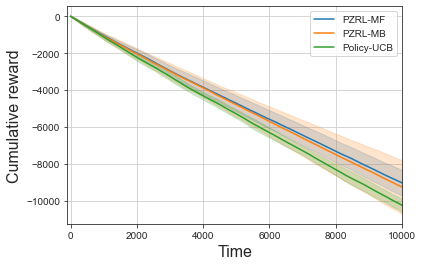

In [14]:
reward_mean, reward_std = {}, {}
for expt in expts:
    reward_mean[expt] = np.mean(rewards[expt],axis=0)
    reward_std[expt] = np.std(rewards[expt],axis=0)
np.save('GriWorld_data.npy', [reward_mean, reward_std])

plt.figure()
plt.tight_layout()
for expt in expts:
    plt.plot(np.arange(1,T+1),reward_mean[expt], color=colors[expt],label=expt_names[expt])
    plt.fill_between(np.arange(1,T+1),reward_mean[expt]-reward_std[expt],
                     reward_mean[expt]+reward_std[expt], color=colors[expt], alpha=0.2)
    plt.legend(fontsize=10,loc='best')
plt.grid()
plt.xlabel('Time',fontsize=16)
plt.ylabel('Cumulative reward',fontsize=16)
plt.xlim(-100,T)
plt.savefig("remotestm_cumul_reward.pdf")

In [15]:
stable_performance = stable_gain*np.arange(1,T+1)
for i in range(repeats):
    for expt in expts:
        regrets[expt][i] = rewards[expt][i] - stable_performance
regret_mean = np.mean(regrets[expt],axis=0)
regret_std = np.std(regrets[expt],axis=0)
np.save('RemoteEstm_data.npy', [reward_mean, reward_std])
np.save('RemoteEstm_reg.npy', [regret_mean, regret_std])

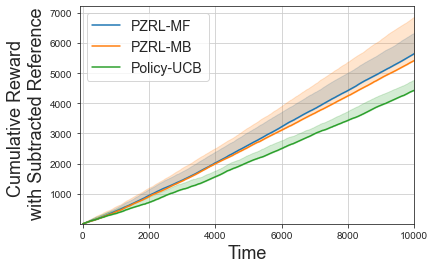

In [16]:
plt.figure()
plt.tight_layout()
for expt in expts:
    plt.plot(np.arange(1,T+1),np.mean(regrets[expt],axis=0), color=colors[expt],label=expt_names[expt])
    plt.fill_between(np.arange(1,T+1),np.mean(regrets[expt],axis=0),
                    np.mean(regrets[expt],axis=0)+np.std(regrets[expt],axis=0), color=colors[expt],alpha=0.2)
    plt.legend(fontsize=14,loc=2)
plt.grid()
plt.xlabel('Time',fontsize=18)
plt.ylabel('Cumulative Reward \n with Subtracted Reference',fontsize=18)
plt.xlim(-100,T)
plt.ylim(1)
plt.savefig("RemoteEstm_Reward.pdf",bbox_inches ="tight")

In [17]:
a, b = pzrlmf(M, T, [10], run, verbose)

In [18]:
def evaluated_policy(param):
    env = remote_estm()
    Horizon = 100000
    sum_rewards = 0
    np.random.seed(1)
    next_state = env.init()
    for t in range(Horizon):
        state = next_state.copy()
        if state[0] >= param[1]*np.abs(state[1]) + param[0]:
            action = 1
        else:
            action = 0
        next_state, reward = env.step(action)
        sum_rewards += reward
    return sum_rewards/Horizon

In [19]:
params = np.zeros((len(b.keys()),3))
for i, key in enumerate(b.keys()):
    params[i,:2] = b[key].param
    params[i,2] = evaluated_policy(params[i,:2])

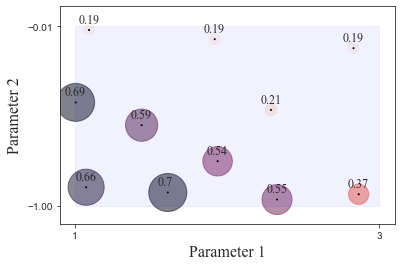

In [20]:
font = FontProperties(family='Times New Roman')

fig, ax = plt.subplots()

square = pat.Rectangle((1, -1), 2, 1-0.01, linewidth=1, edgecolor='blue', facecolor='blue',alpha=0.05)

colors = -5*params[:,2]+10
area =3000*(-1.5-params[:,2])**2

ax.add_patch(square)
ax.set_xlim(0.9, 3.1)
ax.set_ylim(-1.1, 0.1)
ax.set_xticks([1,3])
ax.set_yticks([-1,-0.01])

ax.scatter(params[:,0],params[:,1],s=area, c=colors, alpha=0.5)
ax.scatter(params[:,0],params[:,1],s=np.ones(len(params[:,0])), c='black', alpha=1)
for i in range(len(b.keys())):
    plt.text(params[i,0]-0.07, params[i,1]+0.04, str(np.round(params[i,2]+1.5,2)), fontsize=12, fontproperties=font)
ax.set_xlabel('Parameter 1', fontsize=16, fontproperties=font)
ax.set_ylabel('Parameter 2', fontsize=16, fontproperties=font)
plt.show()
fig.savefig("adapyive_active_policies.pdf",bbox_inches ="tight")

In [21]:
n_1 = 5
n_2 = 5
n_pol = n_1*n_2

params_d1 = np.linspace(1,3,n_1)
params_d2 = np.linspace(-1,-0.001,n_2)

params_u = np.zeros((n_pol,3))
i = 0
for p1, p2 in itertools.product(params_d1, params_d2):
    params_u[i,:2] = np.array([p1,p2])
    params_u[i,2] = evaluated_policy(params_u[i,:2])
    i+= 1

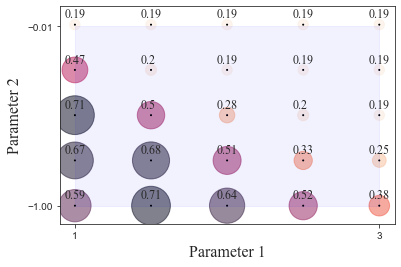

In [22]:
font = FontProperties(family='Times New Roman')

fig, ax = plt.subplots()

square = pat.Rectangle((1, -1), 2, 1-0.01, linewidth=1, edgecolor='blue', facecolor='blue',alpha=0.05)

colors = -5*params_u[:,2]+10
area =3000*(-1.5-params_u[:,2])**2

ax.add_patch(square)
ax.set_xlim(0.9, 3.1)
ax.set_ylim(-1.1, 0.1)
ax.set_xticks([1,3])
ax.set_yticks([-1,-0.01])

ax.scatter(params_u[:,0],params_u[:,1],s=area, c=colors, alpha=0.5)
ax.scatter(params_u[:,0],params_u[:,1],s=np.ones(len(params_u[:,0])), c='black', alpha=1)
for i in range(len(params_u[:,0])):
    plt.text(params_u[i,0]-0.07, params_u[i,1]+0.04, str(np.round(params_u[i,2]+1.5,2)), fontsize=12, fontproperties=font)
ax.set_xlabel('Parameter 1', fontsize=16, fontproperties=font)
ax.set_ylabel('Parameter 2', fontsize=16, fontproperties=font)
plt.show()
fig.savefig("uniform_active_policies.pdf",bbox_inches ="tight")